In [22]:
# Add imports at the top based on the requirements
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import plotly.express as px


In [23]:
X , y = make_classification(
                             n_samples=100, # No of rows
                             n_features=2, # No of columns
                             n_redundant=0, # No of redundant columns
                             n_classes=2, # No of labels for output
                             n_clusters_per_class=1, # No of clusters per label
                             n_informative=1, # No of useful features
                             hypercube=False, 
                             class_sep=10, # Seperation dist between the clusters
                             random_state=54 # Number for replicating this state
)

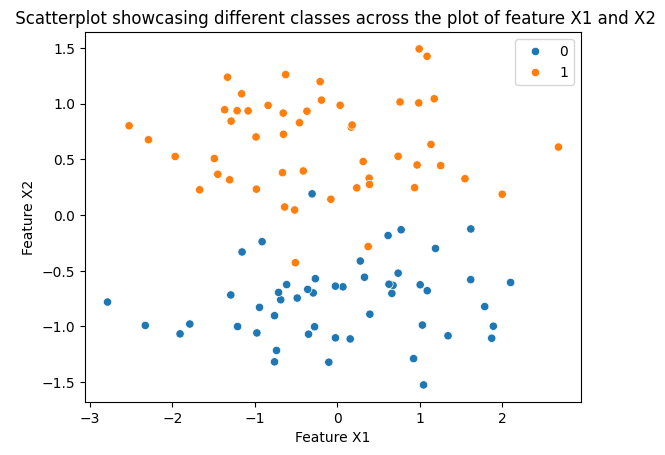

In [24]:
sns.scatterplot(
                    x = X[:,0],
                    y = X[:,1],
                    hue = y
)
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')
plt.title(' Scatterplot showcasing different classes across the plot of feature X1 and X2')
plt.show()

In [25]:
# Now lets make a randm line and we will use it to iterate and make it a classifier that will seperate the boundaries

In [26]:
# Line equation is  : ax + by = c

In [27]:
X = np.insert(X,2,1,axis=1)

In [32]:
X[:5] # This point is added as z axis 

array([[-1.30533845,  0.31682037,  1.        ],
       [ 0.38639547,  0.33180444,  1.        ],
       [-0.65555164,  0.91605548,  1.        ],
       [ 1.25420838,  0.44431404,  1.        ],
       [-0.62634051,  1.26151618,  1.        ]])

In [31]:
y[:5]

array([1, 1, 1, 1, 1])

In [33]:
# the random line : 
# ax + by + c 

In [44]:
X , y = make_classification(
                             n_samples=100, # No of rows
                             n_features=2, # No of columns
                             n_redundant=0, # No of redundant columns
                             n_classes=2, # No of labels for output
                             n_clusters_per_class=1, # No of clusters per label
                             n_informative=1, # No of useful features
                             hypercube=False, 
                             class_sep=10, # Seperation dist between the clusters
                             random_state=54 # Number for replicating this state
)

# Now creating the perceptron from scratch for step function
class pereceptron:
    def __init__(self,learning_rate=0.1,epochs=1000):
        # Instantiate the objects with default values and None appropriately.
        self.lr = learning_rate 
        self.epochs = epochs
        self.coef = None
        self.intercept = None

        # Arrays for m and b in each iteration
        # This step is just done to calculate the slope and intercept here itself so it saves time for plotting the predicted 
        # line that will seperate classes.
        self.m = []
        self.b = []

    def step(self,z):
        # Step function is a function which returns 1 for any value greater than one and 0 for other cases .
        # This is a somewhat not proper and will be addresses later when we compare the models.
        return 1 if z>0 else 0
    
    def fit(self,X,y):
        X = np.insert(X,0,1,axis=1) # Creates a column for the coeffecients of w
        print(f'X = \n{X}')

        w = np.ones(X.shape[1]) # Creates a matrix (1 * n ) where n is the value passed
        print(f'w = {w}')

        print()

        # Now iterating over epochs times:
        for i in range(self.epochs):
            # As the formula : Wnew = Wold - lr*(y - y_hat)*X

            print(f'Iteration : {i}')

            # First lets pick the random point index for the iteration
            j = np.random.randint(0,X.shape[0])
            print(f'j = {j}')

            print(f'X[j] = {X[j]}')
            print(f'y[j] = {y[j]}')

            # Second creating y_hat
            y_hat = self.step(np.dot(X[j],w)) # Call the step function so we can get values 0 or 1
            print(f'y_hat = {y_hat}')

            # Now lets update w (the matrix consisting of the intercept and the coeffecient) value . 
            w = w + self.lr*(y[j] - y_hat)*X[j]
            print(f'updated w = {w}')

            print()
            print()

         # We do this step to extract the coef and intercept which can be later be accessed as objects.
         # We do this outside loop to save computational cost (can be done inside if we are animating inside with plotting methods and libraries).
        self.coef = w[1:]
        self.intercept = w[0]
            
        # The process we did explicilty will be done here automatically
        self.m.append(-(w[1]/w[2])) 
        self.b.append(-(w[0]/w[1]))

        return f"Intercept : {w[0]}  Coeffecient : {w[1:]}"
    
    # Added special method to return the parameters slope and intercept
    def params(self):
        return self.m,self.b
    
    

prc = pereceptron()
prc.fit(X,y) 
    

X = 
[[ 1.         -1.30533845  0.31682037]
 [ 1.          0.38639547  0.33180444]
 [ 1.         -0.65555164  0.91605548]
 [ 1.          1.25420838  0.44431404]
 [ 1.         -0.62634051  1.26151618]
 [ 1.         -0.76079575 -0.90307079]
 [ 1.         -0.29151071 -0.69865925]
 [ 1.          1.04692047 -1.52462663]
 [ 1.          1.0054736  -0.62545662]
 [ 1.          1.13647224  0.63447838]
 [ 1.         -2.52513241  0.80195023]
 [ 1.         -0.36783587  0.93280168]
 [ 1.          0.37447306 -0.28233588]
 [ 1.         -2.3283908  -0.99053579]
 [ 1.          0.31436765  0.48102148]
 [ 1.          0.33023667 -0.55780597]
 [ 1.         -0.26559381 -0.57089337]
 [ 1.         -0.76089029 -1.31743044]
 [ 1.          1.19136751 -0.29930573]
 [ 1.         -1.08151505  0.93548415]
 [ 1.         -1.90689349 -1.06624865]
 [ 1.          2.68255838  0.61077018]
 [ 1.         -1.20897912 -1.00037613]
 [ 1.          0.9930131   1.49184718]
 [ 1.         -0.65291997  0.72578884]
 [ 1.         -0.613

'Intercept : 0.10000000000000014  Coeffecient : [-0.03338533  1.04582839]'